# EXP031: MFI vs MFI oracle — mean across banks 1–5

通常MFIと、真の特性値で項目情報量を評価するoracle MFIを比較します。

- bank 1〜5それぞれのPython版summaryを読み込みます。
- 各stepのRMSEとCumRewardを5バンク間で算術平均します。
- 受検者を全bankで結合してRMSEを再計算するpooled集計ではありません。
- RMSEとCumRewardは別々のFigureへ描画します。


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP031").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


ROOT = find_project_root()
RESULTS_DIR = ROOT / "EXP031" / "results"

BANK_TYPE = "uncor"
BANK_IDS = list(range(1, 6))
TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]

MFI_PATHS = {
    bank_id: RESULTS_DIR / f"summary_{BANK_TYPE}_{bank_id}_MFI_MLE_python.csv"
    for bank_id in BANK_IDS
}
ORACLE_PATHS = {
    bank_id: RESULTS_DIR / f"summary_{BANK_TYPE}_{bank_id}_MFI_oracle_MLE_python.csv"
    for bank_id in BANK_IDS
}

print(f"Project root: {ROOT}")
for bank_id in BANK_IDS:
    print(f"Bank {bank_id} MFI   : {MFI_PATHS[bank_id]}")
    print(f"Bank {bank_id} oracle: {ORACLE_PATHS[bank_id]}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Bank 1 MFI   : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/summary_uncor_1_MFI_MLE_python.csv
Bank 1 oracle: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/summary_uncor_1_MFI_oracle_MLE_python.csv
Bank 2 MFI   : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/summary_uncor_2_MFI_MLE_python.csv
Bank 2 oracle: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/summary_uncor_2_MFI_oracle_MLE_python.csv
Bank 3 MFI   : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/summary_uncor_3_MFI_MLE_python.csv
Bank 3 oracle: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Respo

In [7]:
REQUIRED_COLUMNS = ("step", "RMSE", "CumReward")


def read_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required summary CSV not found: {path}")

    frame = pd.read_csv(path)
    missing = set(REQUIRED_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    frame = frame.copy()
    if not np.isfinite(frame[list(REQUIRED_COLUMNS)].to_numpy()).all():
        raise ValueError(f"{path.name} contains non-finite required values.")

    rounded_steps = frame["step"].round().astype(int)
    if not np.allclose(frame["step"], rounded_steps):
        raise ValueError(f"{path.name} contains non-integer step values.")
    frame["step"] = rounded_steps

    if frame["step"].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate step values.")
    if set(frame["step"]) != set(range(1, TEST_LENGTH + 1)):
        raise ValueError(
            f"{path.name} must contain exactly steps 1 through {TEST_LENGTH}."
        )

    return frame.sort_values("step").reset_index(drop=True)


def read_bank_summaries(paths: dict[int, Path]) -> dict[int, pd.DataFrame]:
    summaries = {bank_id: read_summary(path) for bank_id, path in paths.items()}
    reference_steps = summaries[BANK_IDS[0]]["step"]
    for bank_id, summary in summaries.items():
        if not summary["step"].equals(reference_steps):
            raise ValueError(f"Bank {bank_id} has different step values.")
    return summaries


def mean_across_banks(summaries: dict[int, pd.DataFrame]) -> pd.DataFrame:
    stacked = pd.concat(
        [summary.assign(bank_id=bank_id) for bank_id, summary in summaries.items()],
        ignore_index=True,
    )
    bank_counts = stacked.groupby("step")["bank_id"].nunique()
    if not (bank_counts == len(BANK_IDS)).all():
        raise ValueError("Every step must contain all configured banks.")

    return (
        stacked.groupby("step", as_index=False)[["RMSE", "CumReward"]]
        .mean()
        .sort_values("step")
        .reset_index(drop=True)
    )


mfi_by_bank = read_bank_summaries(MFI_PATHS)
oracle_by_bank = read_bank_summaries(ORACLE_PATHS)
mfi_summary = mean_across_banks(mfi_by_bank)
oracle_summary = mean_across_banks(oracle_by_bank)

if not mfi_summary["step"].equals(oracle_summary["step"]):
    raise ValueError("MFI and oracle MFI mean summaries have different steps.")

print("MFI mean across banks 1-5")
display(mfi_summary.head())
print("Oracle MFI mean across banks 1-5")
display(oracle_summary.head())

MFI mean across banks 1-5


,step,RMSE,CumReward
0,1,1.357818,0.313912
1,2,1.228226,0.540239
2,3,1.105321,0.810592
3,4,1.132465,1.092889
4,5,0.945864,1.380268


Oracle MFI mean across banks 1-5


,step,RMSE,CumReward
0,1,1.733499,0.501553
1,2,1.836101,0.945050
2,3,1.803068,1.367062
3,4,1.585708,1.772359
4,5,1.360746,2.164534


## Mean RMSE across banks 1–5


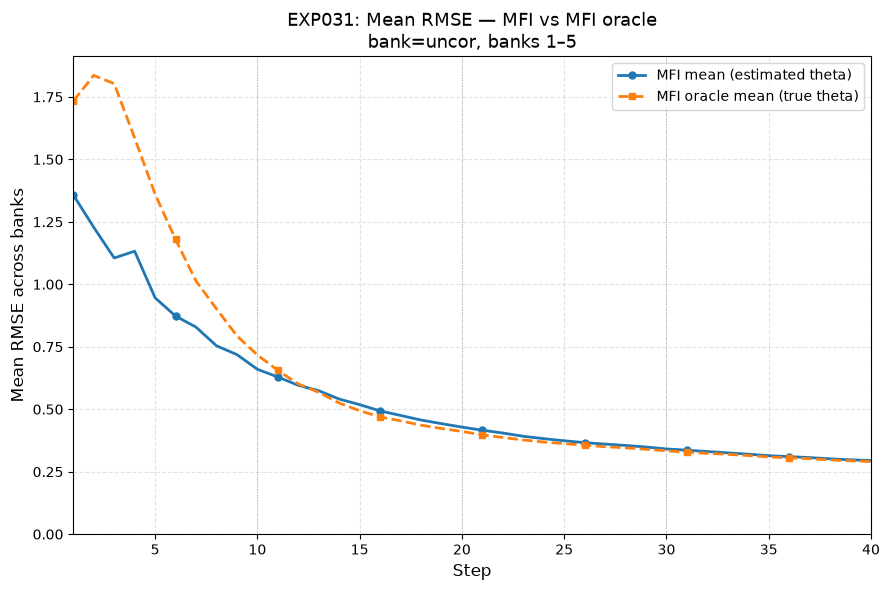

Saved mean RMSE figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/mfi_vs_mfi_oracle_mean_rmse_uncor_banks_1-5.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    mfi_summary["step"],
    mfi_summary["RMSE"],
    color="tab:blue",
    marker="o",
    markevery=5,
    markersize=5,
    linewidth=2.0,
    label="MFI mean (estimated theta)",
)
ax.plot(
    oracle_summary["step"],
    oracle_summary["RMSE"],
    color="tab:orange",
    linestyle="--",
    marker="s",
    markevery=5,
    markersize=5,
    linewidth=2.0,
    label="MFI oracle mean (true theta)",
)

for step in KEY_STEPS:
    ax.axvline(step, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)

ax.set_title(
    f"EXP031: Mean RMSE — MFI vs MFI oracle\nbank={BANK_TYPE}, banks 1–5",
    fontsize=13,
)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Mean RMSE across banks", fontsize=12)
ax.set_xlim(1, TEST_LENGTH)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=10)
fig.tight_layout()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
rmse_output_path = (
    RESULTS_DIR / f"mfi_vs_mfi_oracle_mean_rmse_{BANK_TYPE}_banks_1-5.png"
)
fig.savefig(rmse_output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved mean RMSE figure to: {rmse_output_path}")

## Mean CumReward across banks 1–5


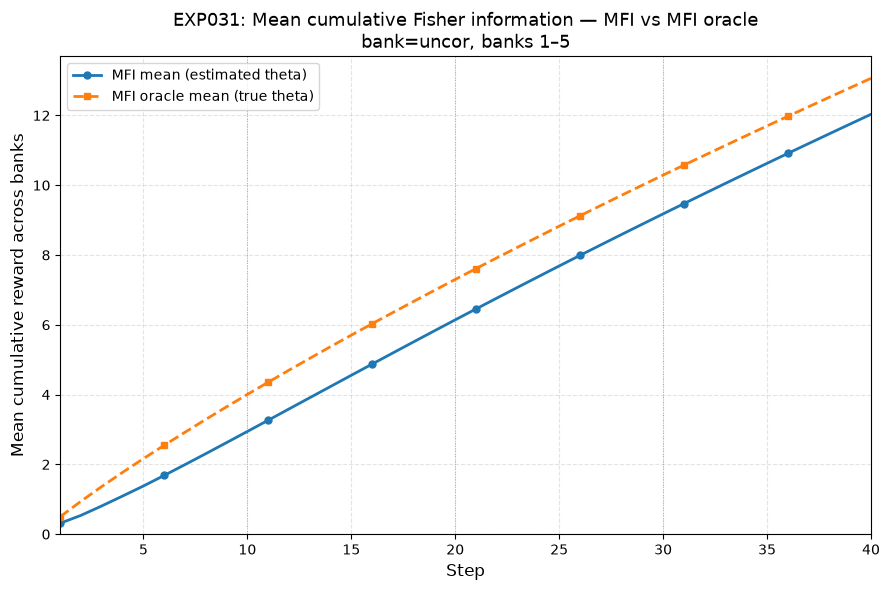

Saved mean CumReward figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/mfi_vs_mfi_oracle_mean_cum_reward_uncor_banks_1-5.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    mfi_summary["step"],
    mfi_summary["CumReward"],
    color="tab:blue",
    marker="o",
    markevery=5,
    markersize=5,
    linewidth=2.0,
    label="MFI mean (estimated theta)",
)
ax.plot(
    oracle_summary["step"],
    oracle_summary["CumReward"],
    color="tab:orange",
    linestyle="--",
    marker="s",
    markevery=5,
    markersize=5,
    linewidth=2.0,
    label="MFI oracle mean (true theta)",
)

for step in KEY_STEPS:
    ax.axvline(step, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)

ax.set_title(
    f"EXP031: Mean cumulative Fisher information — MFI vs MFI oracle\n"
    f"bank={BANK_TYPE}, banks 1–5",
    fontsize=13,
)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Mean cumulative reward across banks", fontsize=12)
ax.set_xlim(1, TEST_LENGTH)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()

cum_reward_output_path = (
    RESULTS_DIR / f"mfi_vs_mfi_oracle_mean_cum_reward_{BANK_TYPE}_banks_1-5.png"
)
fig.savefig(cum_reward_output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved mean CumReward figure to: {cum_reward_output_path}")

## Mean key-step comparison


In [10]:
comparison = mfi_summary.loc[
    mfi_summary["step"].isin(KEY_STEPS), ["step", "RMSE", "CumReward"]
].rename(columns={"RMSE": "RMSE_MFI", "CumReward": "CumReward_MFI"})
comparison = comparison.merge(
    oracle_summary.loc[
        oracle_summary["step"].isin(KEY_STEPS),
        ["step", "RMSE", "CumReward"],
    ].rename(
        columns={
            "RMSE": "RMSE_oracle",
            "CumReward": "CumReward_oracle",
        }
    ),
    on="step",
    validate="one_to_one",
)
comparison["RMSE_oracle_minus_MFI"] = comparison["RMSE_oracle"] - comparison["RMSE_MFI"]
comparison["CumReward_oracle_minus_MFI"] = (
    comparison["CumReward_oracle"] - comparison["CumReward_MFI"]
)

display(comparison)
comparison_output_path = (
    RESULTS_DIR / f"mfi_vs_mfi_oracle_mean_key_steps_{BANK_TYPE}_banks_1-5.csv"
)
comparison.to_csv(comparison_output_path, index=False)
print(f"Saved mean key-step comparison to: {comparison_output_path}")

,step,RMSE_MFI,CumReward_MFI,RMSE_oracle,CumReward_oracle,RMSE_oracle_minus_MFI,CumReward_oracle_minus_MFI
0,10,0.659917,2.943261,0.717324,4.004544,0.057407,1.061282
1,20,0.428439,6.141790,0.411176,7.300136,-0.017263,1.158346
2,30,0.341061,9.178250,0.333598,10.289011,-0.007463,1.110761
3,40,0.294704,12.031372,0.290673,13.062144,-0.004031,1.030772


Saved mean key-step comparison to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/mfi_vs_mfi_oracle_mean_key_steps_uncor_banks_1-5.csv
